In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# House Prices Prediction - Beginner's Guide

## Competition Overview
This notebook explores the **House Prices** dataset and builds a predictive model for house sale prices in Ames, Iowa.

**Goal:** Predict the final sale price of homes based on 79 explanatory variables describing various aspects of residential properties.

**Evaluation Metric:** Root Mean Squared Error (RMSE) between the logarithm of predicted and actual sale prices.

## Notebook Structure
1. **Data Loading & Initial Exploration**
2. **Exploratory Data Analysis (EDA)**
3. **Feature Engineering & Data Preparation**
4. **Machine Learning Modeling**
5. **Conclusions & Next Steps**

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✓ Libraries imported successfully!')

✓ Libraries imported successfully!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Define the base path
base_path = '/content/drive/MyDrive/Colab Notebooks/Coding Camp 2026/house-prices-advanced-regression-techniques/'

# Load the training and test datasets
train_df = pd.read_csv(base_path + 'train.csv')
test_df = pd.read_csv(base_path + 'test.csv')

print(f'✓ Training data shape: {train_df.shape}')
print(f'✓ Test data shape: {test_df.shape}')
print(f'\nFirst few rows of training data:')
display(train_df.head())

Mounted at /content/drive
✓ Training data shape: (1460, 81)
✓ Test data shape: (1459, 80)

First few rows of training data:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Exploratory Data Analysis (EDA)

Let's explore the dataset to understand the patterns, distributions, and relationships between features and the target variable (SalePrice).

In [5]:
# Basic information about the dataset
print('Dataset Info:')
print(f'Number of features: {train_df.shape[1] - 1}')
print(f'Target variable: SalePrice\n')

# Check for missing values
print('Missing values in training data:')
missing_train = train_df.isnull().sum().sort_values(ascending=False)
missing_train_pct = (missing_train / len(train_df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_train, 'Percentage': missing_train_pct})
print(missing_df[missing_df['Missing Count'] > 0].head(10))

# Target variable distribution
print(f'\nSalePrice Statistics:')
print(train_df['SalePrice'].describe())

Dataset Info:
Number of features: 80
Target variable: SalePrice

Missing values in training data:
              Missing Count  Percentage
PoolQC                 1453   99.520548
MiscFeature            1406   96.301370
Alley                  1369   93.767123
Fence                  1179   80.753425
MasVnrType              872   59.726027
FireplaceQu             690   47.260274
LotFrontage             259   17.739726
GarageQual               81    5.547945
GarageFinish             81    5.547945
GarageType               81    5.547945

SalePrice Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


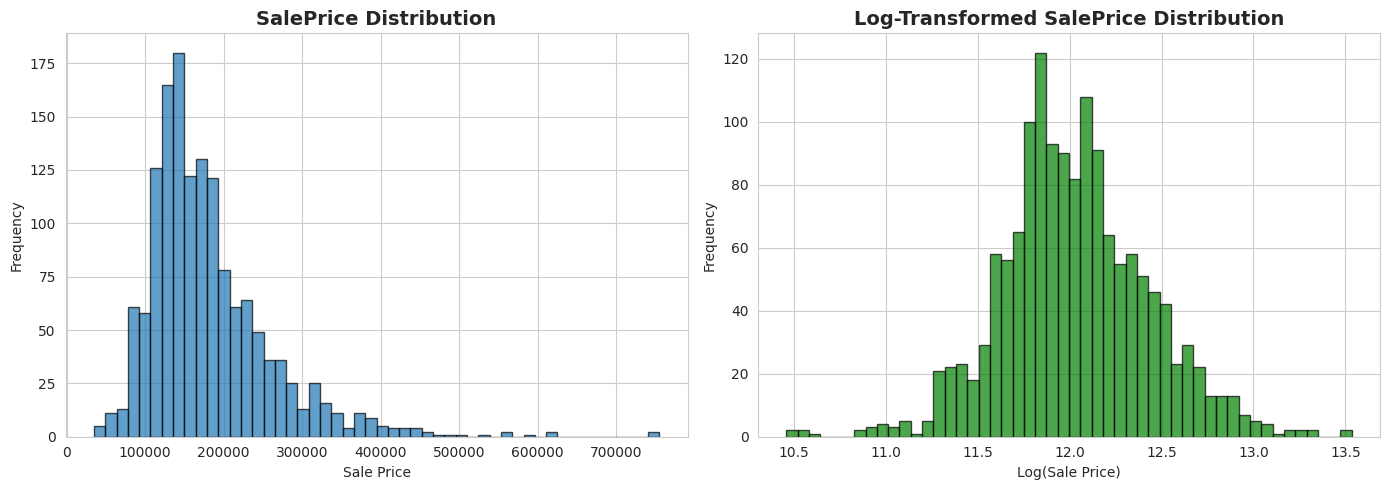

The log transformation makes the distribution more normal, which is better for many ML models.


In [6]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SalePrice distribution
axes[0].hist(train_df['SalePrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('SalePrice Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sale Price')
axes[0].set_ylabel('Frequency')

# Log-transformed SalePrice
axes[1].hist(np.log1p(train_df['SalePrice']), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Log-Transformed SalePrice Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('The log transformation makes the distribution more normal, which is better for many ML models.')

## 2. Feature Engineering & Data Preparation

Now we'll prepare the data for modeling by handling missing values and selecting important features.

In [7]:
# Select important numeric features for simplicity
# For a beginner notebook, we'll use the most important numerical features
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
            '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']

# Prepare training data
X = train_df[features].copy()
y = np.log1p(train_df['SalePrice'])  # Log transform target

# Prepare test data
X_test = test_df[features].copy()

# Handle missing values (fill with median) - FIXED VERSION
for col in features:
    # Calculate median from training data
    median_val = X[col].median()
    # Fill missing values in both training and test data
    X[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

print(f'✓ Selected {len(features)} features')
print(f'✓ Training set: {X.shape}')
print(f'✓ Test set: {X_test.shape}')
print(f'✓ Missing values in X: {X.isnull().sum().sum()}')
print(f'✓ Missing values in X_test: {X_test.isnull().sum().sum()}')
print(f'\nFeatures used: {features}')

✓ Selected 10 features
✓ Training set: (1460, 10)
✓ Test set: (1459, 10)
✓ Missing values in X: 0
✓ Missing values in X_test: 0

Features used: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


## 3. Machine Learning Modeling

Let's train and compare different regression models to predict house prices.

In [8]:
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape}')
print(f'Validation set: {X_val.shape}\n')

# Initialize models
models = {
    'Ridge Regression': Ridge(alpha=10),
    'Lasso Regression': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    results[name] = rmse
    print(f'{name}: RMSE = {rmse:.4f}')

# Find best model
best_model_name = min(results, key=results.get)
print(f'\n★ Best Model: {best_model_name} with RMSE = {results[best_model_name]:.4f}')

Training set: (1168, 10)
Validation set: (292, 10)

Ridge Regression: RMSE = 0.1704
Lasso Regression: RMSE = 0.1702
Random Forest: RMSE = 0.1665
Gradient Boosting: RMSE = 0.1691

★ Best Model: Random Forest with RMSE = 0.1665


In [9]:
# Train Random Forest on full training data
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf_model.fit(X, y)
print('✓ Random Forest model trained on full training data')

# Make predictions on test set
test_predictions_log = rf_model.predict(X_test)

# Convert predictions back from log scale
test_predictions = np.expm1(test_predictions_log)

print(f'✓ Generated predictions for {len(test_predictions)} test samples')

# Create submission dataframe
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print('✓ Submission file created: submission.csv')
print(f'\nFirst few predictions:')
print(submission.head(10))

✓ Random Forest model trained on full training data
✓ Generated predictions for 1459 test samples
✓ Submission file created: submission.csv

First few predictions:
     Id      SalePrice
0  1461  120469.147564
1  1462  148806.561541
2  1463  162257.774370
3  1464  181436.262242
4  1465  213593.935196
5  1466  178546.129578
6  1467  166902.518437
7  1468  177005.685610
8  1469  185794.017420
9  1470  110716.552050


In [10]:
from google.colab import files

# Download the submission file
try:
    files.download('submission.csv')
    print('✓ Download triggered successfully.')
except Exception as e:
    print(f'Error: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download triggered successfully.
